<a href="https://colab.research.google.com/github/paulmunozpauta/Curso_Introduccion_Ciencia_Datos/blob/main/Notebooks/M02_04_Agregacion_exportacion_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://github.com/paulmunozpauta/Curso_Introduccion_Ciencia_Datos/raw/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>

<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Introducción a la Ciencia de Datos</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Introducción a la Ciencia de Datos

## Módulo 2: Organización y preparación de datos

### Notebook 4: Agregación temporal y exportación de datos

En los notebooks anteriores aprendimos a importar, explorar, organizar, seleccionar y limpiar datos. También trabajamos con fechas, índices temporales y control de calidad.

En este notebook aprenderemos a trabajar con datos registrados a diferentes **resoluciones temporales**. Partiremos de observaciones meteorológicas registradas cada **15 minutos** y las transformaremos a escalas horarias, diarias y mensuales.

Este proceso se denomina **agregación temporal** y es una operación frecuente cuando trabajamos con datos ambientales obtenidos mediante sensores automáticos.

También aprenderemos a exportar los datos procesados para utilizarlos posteriormente en otros análisis.

### Objetivos

Al finalizar este notebook podrás:

- identificar la resolución temporal de una serie;
- comprender el concepto de agregación temporal;
- utilizar `resample()` para cambiar la resolución temporal de los datos;
- transformar datos de 15 minutos a escalas horarias, diarias y mensuales;
- aplicar funciones de agregación como `sum()`, `mean()`, `min()` y `max()`;
- seleccionar la función de agregación apropiada según la variable analizada;
- exportar los datos procesados a archivos CSV y Excel.

## Datos utilizados: estación meteorológica CH01 – Campus Chillán UdeC

En este notebook trabajaremos con datos provenientes de la estación meteorológica **CH01**, ubicada en el Campus Chillán de la Universidad de Concepción.

La estación forma parte de un sistema de monitoreo meteorológico de bajo costo que registra automáticamente diferentes variables ambientales.

Entre las variables monitoreadas se encuentran:

- temperatura del aire;
- humedad relativa;
- presión atmosférica;
- precipitación;
- velocidad y dirección del viento;
- radiación solar;
- índice UV.

Los datos de la estación pueden visualizarse en tiempo real en la plataforma **MeteoChillán UdeC**.

**Red de estaciones:**  
https://meteochillan.udec.cl/stations.html

**Estación CH01 – Campus Chillán:**  
https://meteochillan.udec.cl/stations/ch_01.html

Para este ejercicio utilizaremos registros históricos con una **resolución temporal de 15 minutos**.

Trabajar con datos de alta frecuencia nos permitirá estudiar cómo una misma serie puede representarse a diferentes escalas temporales:

**15 minutos → horario → diario → mensual**

## 1. Resolución temporal de los datos

La **resolución temporal** indica el intervalo de tiempo entre observaciones consecutivas de una serie.

Por ejemplo, un sensor que registra información cada 15 minutos genera observaciones como:

| Fecha y hora | Temperatura (°C) |
|---|---:|
| 2026-08-10 10:00 | 8.2 |
| 2026-08-10 10:15 | 8.6 |
| 2026-08-10 10:30 | 9.1 |
| 2026-08-10 10:45 | 9.4 |
| 2026-08-10 11:00 | 9.8 |

En este caso, la resolución temporal de los datos es de **15 minutos**.

Una alta resolución temporal permite observar cambios que ocurren dentro de un mismo día. Sin embargo, dependiendo de la pregunta que queremos responder, puede ser más conveniente trabajar con información horaria, diaria o mensual.

Por ejemplo:

- **15 minutos:** ¿cómo cambia la temperatura durante la mañana?
- **horaria:** ¿cuál fue la temperatura media de cada hora?
- **diaria:** ¿cuál fue la temperatura media, mínima o máxima de cada día?
- **mensual:** ¿cómo cambió la temperatura media entre diferentes meses?

La resolución temporal utilizada depende, por lo tanto, del objetivo del análisis.

## 2. Agregación temporal

La **agregación temporal** consiste en agrupar varias observaciones correspondientes a un determinado intervalo de tiempo y resumirlas mediante una operación.

Por ejemplo, nuestra estación registra cuatro valores de temperatura durante una hora:

| Fecha y hora | Temperatura (°C) |
|---|---:|
| 10:00 | 8.2 |
| 10:15 | 8.6 |
| 10:30 | 9.1 |
| 10:45 | 9.4 |

Estas cuatro observaciones pueden utilizarse para obtener un único valor que represente esa hora.

Por ejemplo, podemos calcular la **temperatura media horaria**.

De esta manera:

**4 observaciones de 15 minutos → 1 observación horaria**

El mismo procedimiento puede aplicarse posteriormente para obtener datos diarios o mensuales:

**15 minutos → horario → diario → mensual**

Al agregar los datos disminuye el número de observaciones y cambia la información representada por cada valor.

## 3. La operación depende de la variable

Agregar datos no significa simplemente cambiar su frecuencia temporal. También debemos decidir **qué operación utilizar para resumir las observaciones**.

La operación apropiada depende de la variable y de la pregunta que queremos responder.

### Temperatura

A partir de observaciones de temperatura cada 15 minutos podemos calcular, por ejemplo:

- `mean()` → temperatura media del periodo;
- `min()` → temperatura mínima del periodo;
- `max()` → temperatura máxima del periodo.

### Precipitación

Si los registros representan la precipitación acumulada durante cada intervalo, podemos utilizar:

- `sum()` → precipitación total acumulada durante el periodo.

Por ejemplo:

**Temperatura cada 15 min → `mean()` → temperatura media horaria**

**Precipitación cada 15 min → `sum()` → precipitación acumulada horaria**

Por lo tanto, antes de realizar una agregación debemos preguntarnos:

1. ¿Qué representa cada observación original?
2. ¿Qué periodo queremos representar?
3. ¿Qué operación tiene sentido para esa variable?

Python puede ejecutar diferentes operaciones matemáticas, pero **no todas tienen necesariamente una interpretación adecuada para la variable analizada**.

## 4. Cargar y explorar los datos de la estación CH01

Ahora trabajaremos con los registros reales de la estación CH01.

Antes de realizar cualquier agregación debemos conocer la estructura del archivo y comprobar:

- qué columnas contiene;
- cómo están almacenadas la fecha y la hora;
- qué variables meteorológicas están disponibles;
- qué unidades utilizan;
- cuántos registros contiene la serie;
- cuál es el periodo disponible.

Primero importaremos las librerías necesarias.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Descargar los datos

Trabajaremos con el archivo **`AW005_2026_08.csv`**, que contiene registros de alta frecuencia de una estación meteorológica de bajo costo.

Descarga el archivo desde el siguiente enlace:

[**Descargar AW005_2026_08.csv**](https://github.com/paulmunozpauta/VLIR_SI_EC_2025-2027/blob/main/datasets/AW005_2026_08.csv)

Una vez descargado, guarda el archivo en tu computador. A continuación lo cargaremos manualmente en Google Colab.

### Cargar el archivo en Google Colab

Los archivos almacenados en nuestro computador no están disponibles automáticamente en Google Colab.

Utilizaremos `files.upload()` para seleccionar y cargar el archivo que acabamos de descargar.

Al ejecutar la siguiente celda:

1. selecciona `AW005_2026_08.csv`;
2. espera hasta que termine la carga;
3. comprueba que aparezca el nombre del archivo.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving AW005_2026_08.csv to AW005_2026_08.csv


### Leer el archivo con Pandas

El archivo se encuentra en formato **CSV** (*Comma-Separated Values*).

Como hemos visto anteriormente, Pandas permite importar este tipo de archivos mediante la función:

`pd.read_csv()`

Guardaremos el contenido en un DataFrame llamado `datos`.

In [4]:
datos = pd.read_csv("AW005_2026_08.csv")

datos.head()

,timestamp,temperature_c,humidity_pct,dew_point_c,feels_like_c,wind_speed_ms,wind_gust_ms,wind_direction_deg,absolute_pressure_hpa,rain_rate_mmhr,yearly_rain_mm,solar_wm2,uv_index,indoor_temp_c,indoor_humidity_pct
0,2025-12-22T18:01:17.609Z,26.0,41.0,11.7,26.0,0.0,0.0,202.0,29.92,0.0,0.0,2.4,0.0,24.9,42.0
1,2025-12-22T19:01:17.852Z,26.3,40.0,11.6,26.3,0.0,0.0,127.0,29.91,0.0,0.8,2.1,0.0,26.1,40.0
2,2025-12-22T20:01:17.232Z,26.9,36.0,10.6,26.6,0.0,0.0,245.0,29.90,0.0,0.3,1.9,0.0,26.7,37.0
3,2025-12-22T21:01:18.421Z,26.8,36.0,10.5,26.5,0.0,0.0,245.0,29.91,0.0,0.3,1.7,0.0,26.4,36.0
4,2025-12-22T22:01:14.613Z,26.5,35.0,9.8,26.5,0.0,0.0,245.0,29.91,0.0,0.3,1.4,0.0,26.1,35.0


`head()` muestra las primeras cinco filas del DataFrame y nos permite realizar una primera inspección de los datos.

Cada fila corresponde a un registro de la estación meteorológica.

Observa:

- la columna que contiene la fecha y hora;
- las variables meteorológicas disponibles;
- los nombres utilizados para las columnas;
- la forma en que están representados los valores.

Antes de realizar cualquier agregación temporal, debemos conocer y preparar correctamente la estructura temporal de estos datos.

### Dimensiones y variables disponibles

Antes de concentrarnos en la dimensión temporal, revisaremos brevemente el tamaño del conjunto de datos y las variables disponibles.

Recordemos que `shape` devuelve:

`(número de filas, número de columnas)`

In [5]:
datos.shape

(15203, 15)

El archivo contiene una gran cantidad de observaciones porque la estación registra información con una frecuencia temporal alta.

Esto es una característica habitual de los sistemas automáticos de monitoreo: incluso periodos relativamente cortos pueden generar miles de registros.

Ahora revisaremos los nombres de las columnas.

In [6]:
datos.columns

Index(['timestamp', 'temperature_c', 'humidity_pct', 'dew_point_c',
       'feels_like_c', 'wind_speed_ms', 'wind_gust_ms', 'wind_direction_deg',
       'absolute_pressure_hpa', 'rain_rate_mmhr', 'yearly_rain_mm',
       'solar_wm2', 'uv_index', 'indoor_temp_c', 'indoor_humidity_pct'],
      dtype='object')


Cada columna representa una variable registrada o calculada por el sistema.

Para este notebook nos concentraremos inicialmente en dos elementos:

- `timestamp`: fecha y hora asociada a cada observación;
- `temperature_C`: temperatura del aire en grados Celsius.

Antes de utilizarlas debemos comprobar cómo fueron interpretadas por Pandas al importar el archivo.

In [7]:
datos.dtypes


,0
timestamp,object
temperature_c,float64
humidity_pct,float64
dew_point_c,float64
feels_like_c,float64
wind_speed_ms,float64
wind_gust_ms,float64
wind_direction_deg,float64
absolute_pressure_hpa,float64
rain_rate_mmhr,float64


## 6. Preparar la fecha y hora

La columna `timestamp` contiene información fundamental para nuestro análisis: indica **cuándo fue realizada cada observación**.

Aunque visualmente observemos fechas y horas, esto no significa necesariamente que Pandas las haya reconocido como información temporal.

Revisemos específicamente el tipo de dato de esta columna.

In [8]:
datos["timestamp"].dtype

dtype('O')

Si el resultado es `object`, Pandas está tratando los valores de `timestamp` como texto y no como fechas y horas.

Para realizar operaciones temporales como:

- seleccionar periodos;
- ordenar cronológicamente;
- calcular intervalos entre observaciones;
- agregar datos por hora, día o mes;

necesitamos convertir esta columna al tipo `datetime`.

Utilizaremos nuevamente `pd.to_datetime()`, pero ahora trabajaremos no solamente con una fecha, sino con **fecha y hora**.

In [9]:
datos["timestamp"] = pd.to_datetime(
    datos["timestamp"]
)

Comprobemos nuevamente el tipo de dato.

In [10]:
datos["timestamp"].dtype

datetime64[ns, UTC]

Ahora `timestamp` debería aparecer como un tipo `datetime`.

Esto permite que Pandas interprete correctamente elementos como:

- año;
- mes;
- día;
- hora;
- minuto.

Al igual que hicimos anteriormente con las series diarias de precipitación, utilizaremos la información temporal como **índice del DataFrame**.

In [11]:
datos = datos.set_index("timestamp")

datos.head()

,temperature_c,humidity_pct,dew_point_c,feels_like_c,wind_speed_ms,wind_gust_ms,wind_direction_deg,absolute_pressure_hpa,rain_rate_mmhr,yearly_rain_mm,solar_wm2,uv_index,indoor_temp_c,indoor_humidity_pct
timestamp,,,,,,,,,,,,,,
2025-12-22 18:01:17.609000+00:00,26.0,41.0,11.7,26.0,0.0,0.0,202.0,29.92,0.0,0.0,2.4,0.0,24.9,42.0
2025-12-22 19:01:17.852000+00:00,26.3,40.0,11.6,26.3,0.0,0.0,127.0,29.91,0.0,0.8,2.1,0.0,26.1,40.0
2025-12-22 20:01:17.232000+00:00,26.9,36.0,10.6,26.6,0.0,0.0,245.0,29.90,0.0,0.3,1.9,0.0,26.7,37.0
2025-12-22 21:01:18.421000+00:00,26.8,36.0,10.5,26.5,0.0,0.0,245.0,29.91,0.0,0.3,1.7,0.0,26.4,36.0
2025-12-22 22:01:14.613000+00:00,26.5,35.0,9.8,26.5,0.0,0.0,245.0,29.91,0.0,0.3,1.4,0.0,26.1,35.0


Ahora cada fila está identificada por la fecha y hora en que se realizó la observación.

Tener un `DatetimeIndex` será fundamental para utilizar posteriormente `resample()`.

Antes de agregar los datos debemos comprobar dos aspectos:

1. que las observaciones estén ordenadas cronológicamente;
2. cuál es realmente el intervalo temporal entre los registros.

Primero verificaremos el orden.

In [12]:
datos.index.is_monotonic_increasing

True

Si obtenemos `True`, las observaciones están ordenadas desde la más antigua hasta la más reciente.

De todas formas, podemos utilizar `sort_index()` para asegurarnos de mantener el orden cronológico.

In [13]:
datos = datos.sort_index()

## 7. ¿Cuál es la resolución temporal de los datos?

La frecuencia de registro de un sistema de monitoreo puede cambiar durante su periodo de operación.

En esta estación, los primeros registros fueron almacenados aproximadamente **cada una hora**. Posteriormente, la configuración del sistema fue modificada para registrar observaciones **cada 15 minutos**.

Además, el momento exacto en que un registro queda almacenado puede presentar pequeñas diferencias de segundos debido al proceso de transmisión y almacenamiento de los datos.

Por esta razón, antes de realizar una agregación temporal, examinaremos directamente cuánto tiempo transcurre entre observaciones consecutivas.

Podemos calcular esta diferencia utilizando `diff()` sobre el índice temporal.

In [29]:
intervalos = datos.index.to_series().diff()

intervalos.head(10)

,timestamp
timestamp,
2025-12-22 18:01:17.609000+00:00,NaT
2025-12-22 19:01:17.852000+00:00,0 days 01:00:00.243000
2025-12-22 20:01:17.232000+00:00,0 days 00:59:59.380000
2025-12-22 21:01:18.421000+00:00,0 days 01:00:01.189000
2025-12-22 22:01:14.613000+00:00,0 days 00:59:56.192000
2025-12-22 23:00:30.608000+00:00,0 days 00:59:15.995000
2025-12-23 00:00:34.026000+00:00,0 days 01:00:03.418000
2025-12-23 01:00:39.429000+00:00,0 days 01:00:05.403000
2025-12-23 02:00:42.979000+00:00,0 days 01:00:03.550000


In [15]:
intervalos.tail(10)

,timestamp
timestamp,
2026-09-28 12:00:00+00:00,0 days 00:15:00
2026-09-28 12:15:00+00:00,0 days 00:15:00
2026-09-28 12:30:00+00:00,0 days 00:15:00
2026-09-28 12:45:00+00:00,0 days 00:15:00
2026-09-28 13:00:00+00:00,0 days 00:15:00
2026-09-28 13:15:00+00:00,0 days 00:15:00
2026-09-28 13:30:00+00:00,0 days 00:15:00
2026-09-28 13:45:00+00:00,0 days 00:15:00
2026-09-28 14:00:00+00:00,0 days 00:15:00


`diff()` calcula la diferencia entre cada fecha y hora y la observación inmediatamente anterior.

El primer registro aparece como `NaT` (*Not a Time*) porque no existe una observación anterior con la cual calcular la diferencia.

Si todos los datos hubieran sido registrados exactamente cada 15 minutos, esperaríamos encontrar repetidamente:

`0 days 00:15:00`

Sin embargo, estamos trabajando con datos reales y sabemos que la frecuencia de registro cambió durante el periodo de funcionamiento de la estación.

Exploremos cuáles son los intervalos más frecuentes.

In [28]:
intervalos.value_counts().head(20)

,count
timestamp,
0 days 00:15:00,11684
0 days 00:30:00,17
0 days 00:45:00,5
0 days 01:00:00.219000,4
0 days 01:00:00.317000,4
0 days 01:00:01.423000,4
0 days 00:59:59.407000,4
0 days 01:00:01.227000,4
0 days 00:59:59.948000,4


El resultado muestra que el intervalo más frecuente es actualmente **15 minutos**.

Sin embargo, también aparecen muchos otros intervalos.

Esto ocurre por dos razones principales:

1. **Cambio en la frecuencia de registro:** durante una primera etapa, la estación registraba información aproximadamente cada hora. Posteriormente, la frecuencia se modificó a 15 minutos.

2. **Pequeñas diferencias en el tiempo de registro:** algunos registros horarios no están separados exactamente por una hora. Por ejemplo, pueden aparecer diferencias como `01:00:00.219` o `00:59:57.527`, asociadas al proceso de transmisión y almacenamiento de la información.

También pueden existir intervalos mayores, por ejemplo 30 o 45 minutos, cuando no se dispone de una observación intermedia.

Este ejemplo muestra una característica importante de los datos obtenidos mediante sistemas automáticos de monitoreo:

> **La frecuencia esperada de medición y los intervalos que observamos realmente en los datos no siempre son exactamente iguales.**

Por esta razón es importante explorar la dimensión temporal antes de realizar una agregación.

### ¿Cuándo cambió la frecuencia de registro?

Podemos visualizar los intervalos entre observaciones a lo largo del tiempo.

Para facilitar la interpretación, transformaremos cada intervalo a minutos.

In [31]:
intervalos_min = intervalos.dt.total_seconds() / 60

intervalos_min.head()

,timestamp
timestamp,
2025-12-22 18:01:17.609000+00:00,NaN
2025-12-22 19:01:17.852000+00:00,60.004050
2025-12-22 20:01:17.232000+00:00,59.989667
2025-12-22 21:01:18.421000+00:00,60.019817
2025-12-22 22:01:14.613000+00:00,59.936533


`total_seconds()` transforma cada intervalo temporal en segundos.

Al dividir por 60 obtenemos el intervalo entre observaciones expresado en **minutos**.

Ahora podemos representarlo gráficamente.

### Visualizar el cambio en la frecuencia de registro

En los resultados anteriores observamos que algunos intervalos entre registros son muy grandes debido a periodos sin observaciones.

Si representamos todos estos intervalos en el mismo gráfico, estos valores dominan la escala vertical y dificultan observar las frecuencias de registro habituales.

Por esta razón, en el siguiente gráfico mostraremos solamente el rango entre **0 y 90 minutos**.

Esto **no elimina ni modifica los datos**. Únicamente cambia el rango visible del gráfico para facilitar la interpretación.

Además, incorporaremos líneas de referencia para:

- **60 minutos**, correspondiente aproximadamente a la frecuencia utilizada inicialmente;
- **15 minutos**, correspondiente a la frecuencia utilizada posteriormente.

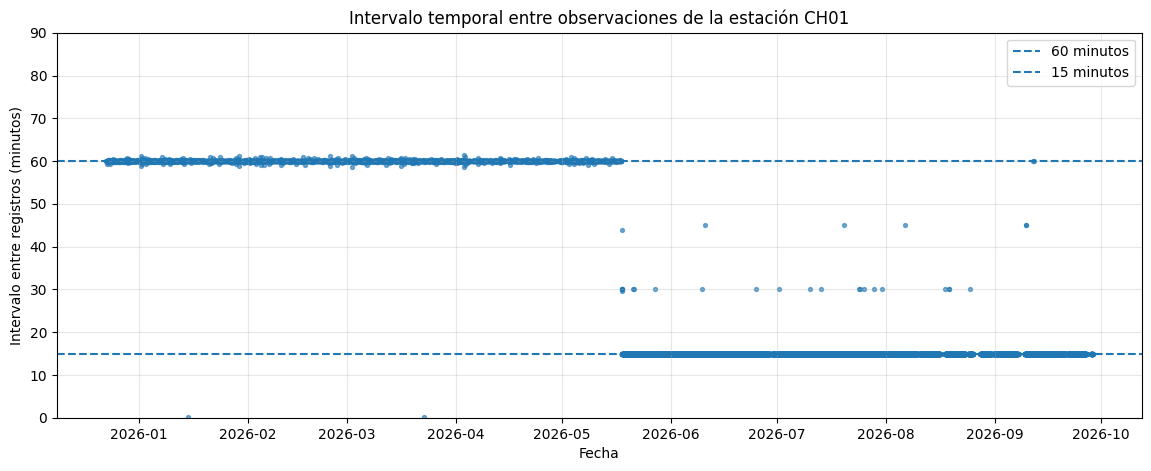

In [33]:
plt.figure(figsize=(14, 5))

plt.scatter(
    intervalos_min.index,
    intervalos_min,
    s=8,
    alpha=0.6
)

# Líneas de referencia
plt.axhline(60, linestyle="--", linewidth=1.5, label="60 minutos")
plt.axhline(15, linestyle="--", linewidth=1.5, label="15 minutos")

# Limitar el eje para observar las frecuencias principales
plt.ylim(0, 90)

plt.xlabel("Fecha")
plt.ylabel("Intervalo entre registros (minutos)")
plt.title("Intervalo temporal entre observaciones de la estación CH01")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

El gráfico permite identificar dos etapas en el funcionamiento de la estación.

Durante la primera parte del registro, las observaciones se encuentran aproximadamente separadas por **60 minutos**. Posteriormente, la frecuencia de adquisición cambia y los registros pasan a estar separados principalmente por **15 minutos**.

También podemos observar interrupciones y algunos intervalos diferentes a las frecuencias esperadas.

Este ejemplo muestra que una serie temporal real no necesariamente presenta una frecuencia perfectamente regular durante todo su periodo de registro.

En la siguiente sección utilizaremos `resample()` para agrupar las observaciones en intervalos temporales definidos.

## 8. Agregación temporal con `resample()`

Ahora que conocemos la estructura temporal de nuestros datos, podemos comenzar a trabajar con diferentes escalas de tiempo.

Pandas proporciona el método `resample()` para **agrupar una serie temporal en intervalos regulares**.

Su funcionamiento general es:

`datos.resample("frecuencia").operacion()`

Debemos indicar dos elementos:

1. **La nueva frecuencia temporal** que queremos obtener.
2. **La operación** que utilizaremos para resumir las observaciones dentro de cada intervalo.

Algunos ejemplos de frecuencias son:

- `"h"` → horario;
- `"D"` → diario;
- `"ME"` → mensual.

Y algunas operaciones que podemos aplicar son:

- `mean()` → media;
- `min()` → mínimo;
- `max()` → máximo;
- `sum()` → suma.

Comenzaremos transformando las observaciones de temperatura de la estación a una resolución **horaria**.